In [8]:
import numpy as np
import pandas as pd
account_balance = np.array([100,250,400,600,800,1000,1200,1500,1800,2200,
    150,300,500,700,900,1100,1400,1700,2000,2500]).reshape(-1, 1)
loan_approved = np.array([0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1])
df = pd.DataFrame({'Account Balance': account_balance.flatten(),'Loan Approved': loan_approved})
print("Dataset:")
print(df)

Dataset:
    Account Balance  Loan Approved
0               100              0
1               250              0
2               400              0
3               600              0
4               800              0
5              1000              1
6              1200              1
7              1500              1
8              1800              1
9              2200              1
10              150              0
11              300              0
12              500              0
13              700              0
14              900              1
15             1100              1
16             1400              1
17             1700              1
18             2000              1
19             2500              1


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(account_balance,loan_approved,test_size=0.3,random_state=42)
print(f"Training: {len(X_train)} | Test: {len(X_test)}")

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print(f"Coefficient: {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")


Training: 14 | Test: 6
Coefficient: 0.1325
Intercept: -112.6142


In [10]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
new_balance = np.array([[1300]])

prediction = model.predict(new_balance)[0]
probability = model.predict_proba(new_balance)[0]

print(f"\nCustomer with Account Balance = $1300")
print(f"Prediction: {'LOAN APPROVED' if prediction == 1 else 'LOAN REJECTED'}")
print(f"Confidence: {max(probability)*100:.1f}%")


Customer with Account Balance = $1300
Prediction: LOAN APPROVED
Confidence: 100.0%


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

accuracy = model.score(X_test, y_test)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba[:,1])

print("---"*15)
print("MODEL EVALUATION")
print("--"*20)
print(f"Accuracy: {accuracy*100:.1f}%")
print(f"AUC Score: {auc:.3f}")
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]} | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]} | True Positives: {cm[1,1]}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=['Rejected','Approved']))

---------------------------------------------
MODEL EVALUATION
----------------------------------------
Accuracy: 100.0%
AUC Score: 1.000

Confusion Matrix:
[[2 0]
 [0 4]]

True Negatives: 2 | False Positives: 0
False Negatives: 0 | True Positives: 4

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         2
    Approved       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



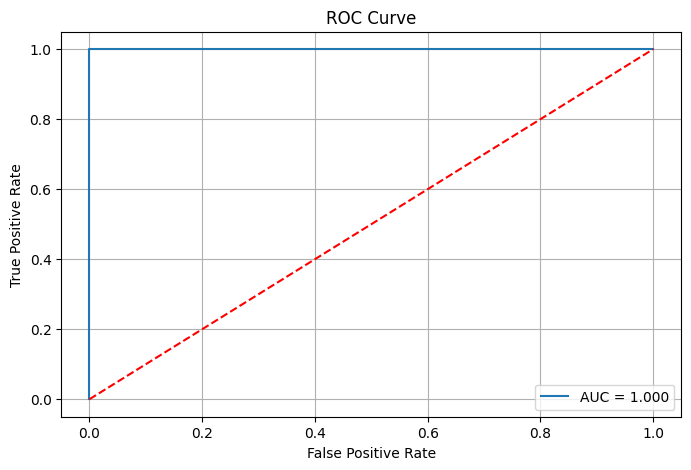

In [12]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba[:,1])

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()